# 🤖 Project 2: Data Classification Using AI
### DecodeLabs | Industrial Training Kit | Batch 2026

---

**Engineer Role:** AI Engineer Intern  
**Project:** Supervised Learning — Data Classification  
**Algorithm:** K-Nearest Neighbors (KNN)  
**Dataset:** Iris Benchmark  
**Framework:** IPO Model → Input | Process | Output  

> *"We do not write the rules. We provide history, and the machine derives the logic."*  
> — DecodeLabs Architecture Briefing


---
## 📐 The Master Blueprint: IPO Framework

The full pipeline for this project follows three phases:

| Phase | Task | Tools |
|---|---|---|
| **INPUT** | Load dataset, explore, scale features | `sklearn.datasets`, `StandardScaler` |
| **PROCESS** | Split data, find optimal K, train model | `train_test_split`, `KNeighborsClassifier` |
| **OUTPUT** | Evaluate with Confusion Matrix & F1 Score | `confusion_matrix`, `f1_score` |


---
## 📦 Step 0 — Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets        import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (classification_report,
                                      confusion_matrix,
                                      f1_score, accuracy_score)

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## 🔵 PHASE 1 — INPUT
### Step 1: Load & Explore the Iris Benchmark Dataset

The **Iris dataset** is the industry-standard benchmark for classification:

| Property | Value |
|---|---|
| Total Samples | 150 (Balanced) |
| Classes | 3 — Setosa, Versicolor, Virginica |
| Features | 4 — Sepal Length, Sepal Width, Petal Length, Petal Width |

A **balanced dataset** means each class has exactly 50 samples — no class imbalance to worry about here.


In [2]:
# Load the dataset
iris = load_iris()
X    = iris.data    # Features  (150 × 4 matrix)
y    = iris.target  # Labels    (0, 1, or 2)

# Wrap in a DataFrame for readability
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {list(iris.target_names)}")
print(f"Samples/class : {np.bincount(y).tolist()}  ✅ Balanced\n")
df.head(10)


Dataset shape : (150, 4)
Classes       : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Samples/class : [50, 50, 50]  ✅ Balanced



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### Step 2: Descriptive Statistics

Understanding your data *before* training is a non-negotiable professional habit.


In [3]:
df.describe().round(2)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Step 3: Visualise Class Distribution


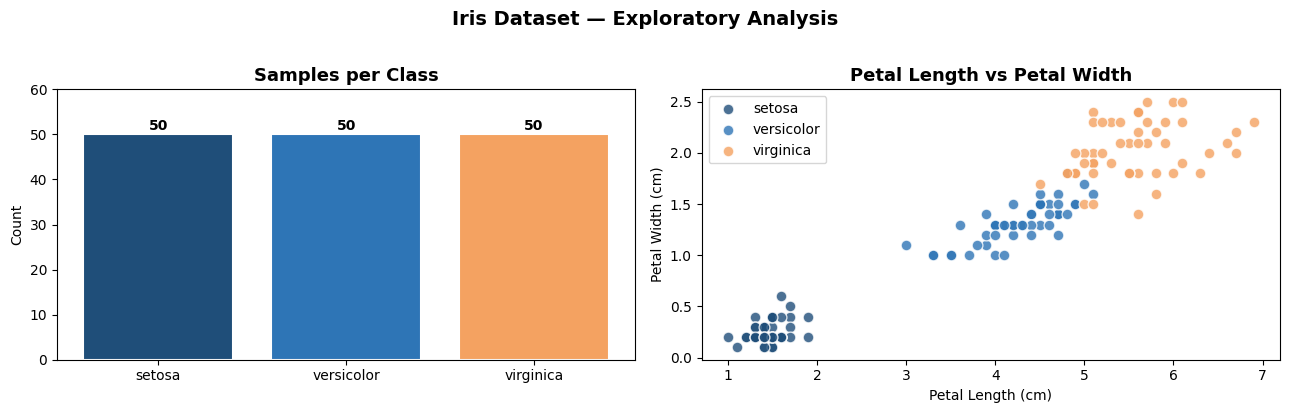

📊 Notice: Setosa is linearly separable. Versicolor/Virginica overlap slightly.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -- Bar chart: samples per class
counts = df['species'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#1f4e79', '#2e75b6', '#f4a261'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Samples per Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 60)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# -- Petal scatter: best separating features
colors = {'setosa': '#1f4e79', 'versicolor': '#2e75b6', 'virginica': '#f4a261'}
for species, grp in df.groupby('species'):
    axes[1].scatter(grp['petal length (cm)'], grp['petal width (cm)'],
                    label=species, color=colors[species], alpha=0.8, edgecolors='white', s=60)
axes[1].set_title('Petal Length vs Petal Width', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()

plt.suptitle('Iris Dataset — Exploratory Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("📊 Notice: Setosa is linearly separable. Versicolor/Virginica overlap slightly.")


### Step 4: The Gatekeeper Rule — Feature Scaling

KNN is a **distance-based algorithm**. Without scaling, a feature with large values (e.g. 0–1000) will completely dominate a feature with small values (e.g. 0–1), creating a **biased distance metric**.

`StandardScaler` transforms every feature to **Mean = 0, Variance = 1**, giving each equal weight.

> ⚠️ **Critical Rule:** Fit the scaler **only on training data**, then transform both sets.  
> Fitting on the full dataset would cause **data leakage** — the model would peek at test information.


In [5]:
# ── Train / Test Split (80% / 20%) with shuffle ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    shuffle      = True   # removes order bias
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

# ── Feature Scaling ──
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train only
X_test  = scaler.transform(X_test)        # transform only — NO fit

print(f"\nScaling applied  : StandardScaler ✅")
print(f"Train mean (post-scale): {X_train.mean(axis=0).round(4)}  → ~0")
print(f"Train std  (post-scale): {X_train.std(axis=0).round(4)}   → ~1")


Training samples : 120
Testing  samples : 30

Scaling applied  : StandardScaler ✅
Train mean (post-scale): [ 0. -0. -0. -0.]  → ~0
Train std  (post-scale): [1. 1. 1. 1.]   → ~1


---
## ⚙️ PHASE 2 — PROCESS
### Step 5: The Elbow Method — Finding Optimal K

**K** is the only hyperparameter in KNN — it controls how many neighbours vote on a classification.

- **K too small (K=1):** Overfitting — sensitive to noise
- **K too large (K=100):** Underfitting — too generic
- **Optimal K:** The "elbow" — lowest error rate

We scan odd K values to avoid tie votes in majority voting.


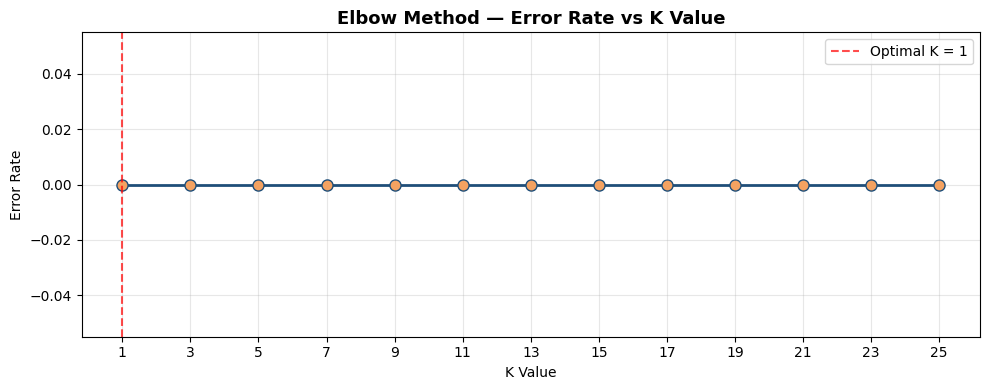

✅ Optimal K = 1  |  Error Rate = 0.0000


In [6]:
error_rates = []
k_range     = range(1, 26, 2)   # odd K values: 1, 3, 5 ... 25

for k in k_range:
    knn  = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred))

# Plot the elbow curve
plt.figure(figsize=(10, 4))
plt.plot(list(k_range), error_rates, 'o-', color='#1f4e79',
         linewidth=2, markersize=8, markerfacecolor='#f4a261')
plt.title('Elbow Method — Error Rate vs K Value', fontsize=13, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)

best_k = list(k_range)[error_rates.index(min(error_rates))]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal K = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"✅ Optimal K = {best_k}  |  Error Rate = {min(error_rates):.4f}")


### Step 6: Train the Model

The scikit-learn workflow from the spec:
1. **Instantiate** — build the frame
2. **Fit** — memorize the map (training data)
3. **Predict** — apply logic to unseen data


In [7]:
# ── Instantiate ──
model = KNeighborsClassifier(n_neighbors=best_k)

# ── Fit (Train) ──
model.fit(X_train, y_train)

# ── Predict ──
y_pred = model.predict(X_test)

print(f"Model     : KNeighborsClassifier(n_neighbors={best_k})")
print(f"Status    : Trained ✅")
print(f"Test preds: {y_pred}")
print(f"Actual    : {y_test}")


Model     : KNeighborsClassifier(n_neighbors=1)
Status    : Trained ✅
Test preds: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual    : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


---
## 📊 PHASE 3 — OUTPUT
### Step 7: Output Validation — Beyond the Accuracy Mirage

> *"In imbalanced data, accuracy is a lie. We must look deeper."* — DecodeLabs

Even on balanced data, we always report **Confusion Matrix + F1 Score** as the professional standard.

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall correct predictions |
| **Precision** | Of all predicted positives, how many were real? (Spam filter) |
| **Recall** | Of all actual positives, how many did we catch? (Medical diagnosis) |
| **F1 Score** | Harmonic mean of Precision & Recall — the balanced truth |


In [8]:
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("=" * 45)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  F1 Score : {f1:.4f}  (Weighted Harmonic Mean)")
print("=" * 45)


  Accuracy : 1.0000  (100.0%)
  F1 Score : 1.0000  (Weighted Harmonic Mean)


### Step 8: Confusion Matrix — The Diagnostic Tool

Rows = Actual class | Columns = Predicted class  
**Perfect model:** all values on the diagonal (zero off-diagonal entries).


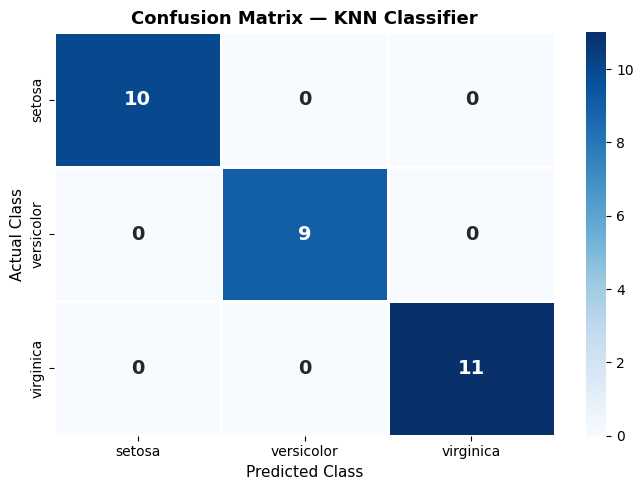

✅ Diagonal = True Positives (correct predictions per class)
❌ Off-diagonal = misclassifications (FP / FN)


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix — KNN Classifier', fontsize=13, fontweight='bold')
plt.ylabel('Actual Class',    fontsize=11)
plt.xlabel('Predicted Class', fontsize=11)
plt.tight_layout()
plt.show()

print("✅ Diagonal = True Positives (correct predictions per class)")
print("❌ Off-diagonal = misclassifications (FP / FN)")


### Step 9: Full Classification Report


In [10]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Step 10: Feature Analysis — Which Features Matter Most?


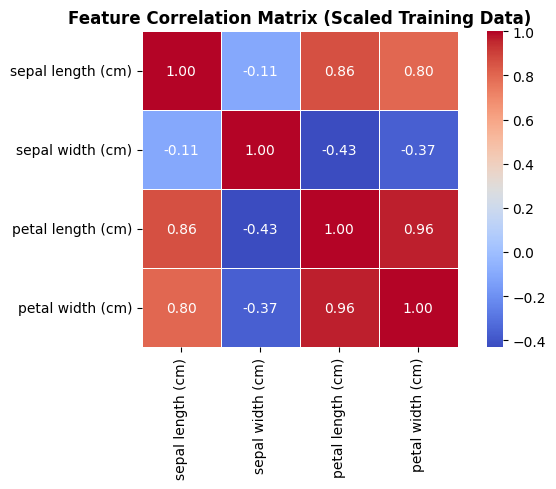

High petal length/width correlation → they carry overlapping information.


In [11]:
# Correlation heatmap of features
plt.figure(figsize=(7, 5))
feature_df = pd.DataFrame(X_train, columns=iris.feature_names)
sns.heatmap(feature_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix (Scaled Training Data)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("High petal length/width correlation → they carry overlapping information.")


---
## 🚀 Step 11: Live Prediction — New Unseen Sample

Test the trained model on a brand-new flower measurement not in the dataset.


In [12]:
# New flower measurements [sepal_len, sepal_wid, petal_len, petal_wid]
new_samples = [
    [5.1, 3.5, 1.4, 0.2],   # Expected: Setosa
    [6.3, 3.3, 4.7, 1.6],   # Expected: Versicolor
    [7.2, 3.0, 5.8, 1.6],   # Expected: Virginica
]

print(f"{'Sample':<35} {'Predicted':<15} {'Confidence'}")
print("-" * 70)

for sample in new_samples:
    scaled     = scaler.transform([sample])
    pred       = model.predict(scaled)[0]
    proba      = model.predict_proba(scaled)[0]
    confidence = proba.max()
    species    = iris.target_names[pred]
    print(f"{str(sample):<35} {species:<15} {confidence:.1%}")


Sample                              Predicted       Confidence
----------------------------------------------------------------------
[5.1, 3.5, 1.4, 0.2]                setosa          100.0%
[6.3, 3.3, 4.7, 1.6]                versicolor      100.0%
[7.2, 3.0, 5.8, 1.6]                virginica       100.0%


---
## ✅ Project 2 — Summary

| Component | Decision | Reason |
|---|---|---|
| Dataset | Iris (150 samples) | Balanced benchmark, 4 clean features |
| Scaling | StandardScaler | KNN is distance-based — scaling is mandatory |
| Split | 80% train / 20% test | Industry standard; shuffle removes order bias |
| Algorithm | K-Nearest Neighbors | Simple, interpretable, no training phase |
| K Selection | Elbow Method | Avoids overfitting (K=1) and underfitting (K=100) |
| Evaluation | F1 Score + Confusion Matrix | Accuracy alone is misleading on real-world data |

### Key Takeaways
- **Supervised learning** = provide labelled history → machine derives the boundary
- **Feature scaling is not optional** for distance-based algorithms
- **F1 Score** is the true north metric — accuracy can lie on imbalanced data
- **Confusion matrix** tells you *where* the model fails, not just *how often*

---
> *"Your journey to becoming a professional AI engineer begins right here, right now,  
> with the very first model you train today."* — DecodeLabs
